# LangSight — YOLOv11n Evaluation (9 Class)

Capstone 29 | S1 Sains Data | Universitas Telkom

Evaluasi model YOLOv11n fine-tuned pada 9 kelas target.
Output: `eval_summary_yolo.json` untuk WBF Ensemble notebook.

Persiapan:
1. Runtime → Change runtime type → T4 GPU
2. Upload `langsight_best_pt.zip` dan `gt_review.json` ke `/content/`
3. Run All
4. Download `eval_summary_yolo.json`


In [1]:
!pip install ultralytics roboflow opencv-python pillow numpy pandas \
             matplotlib seaborn scikit-learn tqdm -q

import os, re, json, time, warnings, math, gc
import random
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import precision_recall_curve, average_precision_score
import torch
import yaml

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110
random.seed(42); np.random.seed(42)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    cc = torch.cuda.get_device_capability(0)
    print(f'Compute : {cc[0]}.{cc[1]}')
print('Import selesai.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 124.5 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
Compute : 7.5
Import selesai.


In [2]:
# ── Konstanta (SYNCED dengan app.py v7.0 dan DINO eval notebook) ─────────────
ROBOFLOW_API_KEY = 'L3OgcMAfQualsYoVK5K5'
BASE     = Path('/content')
DATA_DIR = BASE / 'eval_datasets'
OUT_DIR  = BASE / 'eval_results_yolo'
MODEL_ZIP = BASE / 'langsight_best_pt.zip'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_9_CLASSES = ['pen', 'pencil', 'eraser', 'sharpener', 'correction_tape', 'stapler', 'clip', 'bottle', 'notebook']

# YOLO punya 6 dari 9 kelas (tissue & scissor di-drop, sharpener/clip/notebook tidak ada)
YOLO_TO_TARGET = {'pen': 'pen', 'pencil': 'pencil', 'eraser': 'eraser', 'stapler': 'stapler', 'correction_tape': 'correction_tape', 'bottle': 'bottle'}
YOLO_EVAL_CLASSES  = list(YOLO_TO_TARGET.values())
YOLO_MISSING_CLASSES = [c for c in TARGET_9_CLASSES if c not in YOLO_EVAL_CLASSES]

# Adaptive IoU — IDENTIK dengan app.py dan DINO eval
ADAPTIVE_IOU = {'pen': 0.3, 'pencil': 0.3, 'clip': 0.3, 'correction_tape': 0.35, 'stapler': 0.4}
IOU_THRESHOLD   = 0.5
CONF_THRESHOLD  = 0.25
MIN_GT = 5

CLASS_MAP = {'pen': 'pen', 'ballpen': 'pen', 'ballpoint': 'pen', 'ball point': 'pen', 'ballpoint pen': 'pen', 'gel pen': 'pen', 'signpen': 'pen', 'sign pen': 'pen', 'fineliner': 'pen', 'ink pen': 'pen', 'rollerball pen': 'pen', 'felt tip pen': 'pen', 'writing pen': 'pen', 'drawing pen': 'pen', 'pencil': 'pencil', 'mechanical pencil': 'pencil', 'graphite pencil': 'pencil', 'wooden pencil': 'pencil', 'hb pencil': 'pencil', '2b pencil': 'pencil', 'lead pencil': 'pencil', 'drafting pencil': 'pencil', 'eraser': 'eraser', 'pencil eraser': 'eraser', 'white eraser': 'eraser', 'eraser block': 'eraser', 'rubber eraser': 'eraser', 'rubber': 'eraser', 'sharpener': 'sharpener', 'sharpner': 'sharpener', 'pencil sharpener': 'sharpener', 'handheld sharpener': 'sharpener', 'correction tape': 'correction_tape', 'correctiontape': 'correction_tape', 'correction pen': 'correction_tape', 'tipex': 'correction_tape', 'tipp-ex': 'correction_tape', 'white-out': 'correction_tape', 'whiteout': 'correction_tape', 'liquid paper': 'correction_tape', 'correction-tape': 'correction_tape', 'white out tape': 'correction_tape', 'correction roller': 'correction_tape', 'tipex tape roller': 'correction_tape', 'stapler': 'stapler', 'paper stapler': 'stapler', 'office stapler': 'stapler', 'manual stapler': 'stapler', 'objects': 'stapler', 'paper clip': 'clip', 'paperclip': 'clip', 'binder clip': 'clip', 'clip': 'clip', 'bulldog clip': 'clip', 'foldback clip': 'clip', 'metal clip': 'clip', 'document clip': 'clip', 'metal paperclip': 'clip', 'bottle': 'bottle', 'water bottle': 'bottle', 'waterbottle': 'bottle', 'tumbler': 'bottle', 'drink bottle': 'bottle', 'flask': 'bottle', 'bottle_detect': 'bottle', 'beverage container': 'bottle', 'plastic bottle': 'bottle', 'drink': 'bottle', 'notebook': 'notebook', 'exercise book': 'notebook', 'notepad': 'notebook', 'spiral notebook': 'notebook', 'writing notebook': 'notebook', 'composition book': 'notebook', 'lined notebook': 'notebook', 'school notebook': 'notebook', 'memo pad': 'notebook'}

print(f'9 kelas target   : {TARGET_9_CLASSES}')
print(f'YOLO punya       : {YOLO_EVAL_CLASSES}')
print(f'YOLO tidak punya : {YOLO_MISSING_CLASSES}')
print(f'CONF threshold   : {CONF_THRESHOLD}')
print(f'IOU threshold    : {IOU_THRESHOLD}')


9 kelas target   : ['pen', 'pencil', 'eraser', 'sharpener', 'correction_tape', 'stapler', 'clip', 'bottle', 'notebook']
YOLO punya       : ['pen', 'pencil', 'eraser', 'stapler', 'correction_tape', 'bottle']
YOLO tidak punya : ['sharpener', 'clip', 'notebook']
CONF threshold   : 0.25
IOU threshold    : 0.5


In [3]:
# Verifikasi file
for fpath, name in [(MODEL_ZIP, 'langsight_best_pt.zip'),
                    (BASE/'gt_review.json','gt_review.json')]:
    alt = list(BASE.glob('gt_review*.json')) if 'gt_review' in name else []
    p = alt[0] if alt else fpath
    if p.exists():
        print(f'  OK   {p.name} ({p.stat().st_size/1024:.1f} KB)')
    else:
        print(f'  MISS {name} — upload ke /content/ dulu')


  OK   langsight_best_pt.zip (5318.0 KB)
  OK   gt_review.json (40.0 KB)


In [4]:
# Load YOLOv11n dari zip checkpoint
from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

print(f'Loading dari {MODEL_ZIP}...')
ckpt = torch.load(str(MODEL_ZIP), map_location='cpu', weights_only=False)
print(f'  Versi ultralytics : {ckpt["version"]}')
print(f'  Tanggal training  : {ckpt["date"]}')
tm = ckpt.get('train_metrics', {})
print(f'  Train mAP@50      : {tm.get("metrics/mAP50(B)", 0):.4f}')
print(f'  Train Recall      : {tm.get("metrics/recall(B)", 0):.4f}')
print(f'  Train Precision   : {tm.get("metrics/precision(B)", 0):.4f}')
print(f'  Kelas YOLO native : {ckpt["model"].names}')

model_raw = ckpt['model'].float().to(DEVICE).eval()
tmp_pt    = '/content/_yolo_tmp.pt'
torch.save({'model': model_raw, 'names': model_raw.names}, tmp_pt)
yolo_model = YOLO(tmp_pt)
yolo_model.to(DEVICE)

# Warmup
_ = yolo_model.predict(np.zeros((640,640,3), dtype=np.uint8), verbose=False, conf=0.01)
print('Warmup selesai.')
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info(0)
    print(f'VRAM: {free/1e9:.1f}/{total/1e9:.1f} GB free')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda
Loading dari /content/langsight_best_pt.zip...
  Versi ultralytics : 8.4.47
  Tanggal training  : 2026-05-07T10:33:21.989561
  Train mAP@50      : 0.9644
  Train Recall      : 0.9231
  Train Precision   : 0.9498
  Kelas YOLO native : {0: 'pen', 1: 'pencil', 2: 'eraser', 3: 'stapler', 4: 'correction_tape', 5: 'tissue', 6: 'bottle', 7: 'scissor'}
Warmup selesai.
VRAM: 15.4/15.6 GB free


In [5]:
# Download dataset Roboflow
from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

EVAL_DATASETS = [{'name': 'ds_stationary', 'workspace': 'national-university-fast', 'project': 'stationary-items-dataset', 'version': 8, 'desc': 'pen, pencil, eraser, ruler, notebook'}, {'name': 'ds_stationery', 'workspace': '65704680', 'project': 'stationery-clhrb', 'version': 6, 'desc': 'pen, pencil, eraser, scissors'}, {'name': 'ds_correction_tape', 'workspace': 'han-sy', 'project': 'correction-tape', 'version': 3, 'desc': 'correction_tape'}, {'name': 'ds_stapler', 'workspace': 'kavya-5k61i', 'project': 'stapler-yrkcg', 'version': 1, 'desc': 'stapler'}, {'name': 'ds_clip', 'workspace': 'multimedia', 'project': 'clip-xs5dn', 'version': 1, 'desc': 'clip'}, {'name': 'ds_bottle', 'workspace': 'aaaa-lg0ki', 'project': 'bottle-detection-ak5ic', 'version': 1, 'desc': 'bottle'}]

downloaded = {}
for ds in EVAL_DATASETS:
    dst = DATA_DIR / ds['name']
    if dst.exists() and any(dst.rglob('*.jpg')):
        print(f"  {ds['name']}: sudah ada, skip")
        downloaded[ds['name']] = dst
        continue
    print(f"  Download {ds['name']} ({ds['desc']})...")
    try:
        rf.workspace(ds['workspace']).project(ds['project']) \
          .version(ds['version']).download('yolov11', location=str(dst))
        downloaded[ds['name']] = dst
        print('    OK')
    except Exception as e:
        print(f'    GAGAL: {e}')

print(f'\nDownload selesai: {len(downloaded)}/{len(EVAL_DATASETS)} dataset')
print(f'Dataset tersedia : {list(downloaded.keys())}')


  Download ds_stationary (pen, pencil, eraser, ruler, notebook)...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/eval_datasets/ds_stationary in yolov11:: 100%|██████████| 2336/2336 [00:01<00:00, 1945.18it/s]

    OK
  Download ds_stationery (pen, pencil, eraser, scissors)...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/eval_datasets/ds_stationery in yolov11:: 100%|██████████| 438/438 [00:00<00:00, 8436.34it/s]

...


Extracting Dataset Version Zip to /content/eval_datasets/ds_clip in yolov11:: 100%|██████████| 105/105 [00:00<00:00, 9719.11it/s]

    OK
  Download ds_bottle (bottle)...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/eval_datasets/ds_bottle in yolov11:: 100%|██████████| 2486/2486 [00:00<00:00, 8904.25it/s]

    OK

Download selesai: 6/6 dataset
Dataset tersedia : ['ds_stationary', 'ds_stationery', 'ds_correction_tape', 'ds_stapler', 'ds_clip', 'ds_bottle']


In [6]:
# Parse Ground Truth
def parse_gt(ds_root, split='val'):
    yaml_path = next(ds_root.rglob('data.yaml'), None)
    if not yaml_path: return []
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    classes = cfg.get('names', [])
    if isinstance(classes, dict):
        classes = [classes[k] for k in sorted(classes.keys())]
    img_dir = None
    for s in [split,'valid','val','test','train']:
        d = next((x for x in ds_root.rglob(f'{s}/images') if x.is_dir()), None)
        if d: img_dir = d; break
    if not img_dir: return []
    lbl_dir = img_dir.parent / 'labels'
    if not lbl_dir.exists(): return []
    records = []
    n_total = n_mapped = n_tiny = n_out = 0
    for lp in sorted(lbl_dir.glob('*.txt')):
        imgs = [p for p in img_dir.glob(lp.stem+'.*')
                if p.suffix.lower() in ('.jpg','.jpeg','.png','.bmp')]
        if not imgs: continue
        boxes = []
        with open(lp) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts)<5: continue
                try: oid = int(float(parts[0]))
                except ValueError: continue
                if oid >= len(classes): continue
                n_total += 1
                raw = re.sub(r'\s+',' ',classes[oid].lower().strip())
                raw2 = raw.split(' - ')[0].split(' v')[0].strip()
                gt_cls = CLASS_MAP.get(raw) or CLASS_MAP.get(raw2)
                if not gt_cls and raw=='objects' and 'stapler' in str(ds_root).lower():
                    gt_cls = 'stapler'
                if not gt_cls: continue
                if gt_cls not in TARGET_9_CLASSES: n_out+=1; continue
                try: cx,cy,bw,bh = map(float,parts[1:5])
                except ValueError: continue
                if not (0<bw<=1 and 0<bh<=1): continue
                if bw*bh < 0.0005: n_tiny+=1; continue
                n_mapped += 1
                boxes.append({'class':gt_cls,'bbox_norm':[cx,cy,bw,bh]})
        if boxes:
            records.append({'img_path':imgs[0],'ds_name':ds_root.name,'boxes':boxes})
    print(f'  {ds_root.name:<25} img={len(records):<4} '
          f'box(total={n_total} mapped={n_mapped} outside9={n_out} tiny={n_tiny})')
    return records

print('Parse ground truth:')
DS_PRIORITY = ['ds_stationary', 'ds_stationery', 'ds_correction_tape', 'ds_stapler', 'ds_clip', 'ds_bottle']
records_per_ds = {}
for ds_name in DS_PRIORITY:
    if ds_name in downloaded:
        records_per_ds[ds_name] = parse_gt(downloaded[ds_name])

all_records = []
seen = set()
for ds_name in DS_PRIORITY:
    for rec in records_per_ds.get(ds_name,[]):
        if rec['img_path'] in seen: continue
        seen.add(rec['img_path']); all_records.append(rec)

gt_cls_count = Counter(b['class'] for r in all_records for b in r['boxes'])
print(f'\nTotal gambar : {len(all_records)}')
print(f'Total bbox   : {sum(gt_cls_count.values())}')
print(f'\nDistribusi:')
for cls in sorted(gt_cls_count, key=lambda x:-gt_cls_count[x]):
    bar = '#'*min(30,gt_cls_count[cls]//5)
    print(f'  {cls:<22} {gt_cls_count[cls]:>5}  {bar}')


Parse ground truth:
  ds_stationary             img=130  box(total=369 mapped=260 outside9=0 tiny=0)
  ds_stationery             img=9    box(total=15 mapped=10 outside9=0 tiny=0)
  ds_correction_tape        img=5    box(total=5 mapped=5 outside9=0 tiny=0)
  ds_stapler                img=20   box(total=28 mapped=28 outside9=0 tiny=0)
  ds_clip                   img=11   box(total=13 mapped=13 outside9=0 tiny=0)
  ds_bottle                 img=214  box(total=348 mapped=347 outside9=0 tiny=1)

Total gambar : 389
Total bbox   : 663

Distribusi:
  bottle                   347  ##############################
  pencil                    87  #################
  pen                       54  ##########
  eraser                    49  #########
  sharpener                 45  #########
  notebook                  35  #######
  stapler                   28  #####
  clip                      13  ##
  correction_tape            5  #


In [7]:
# Filter gt_review.json
REVIEW_FILE = sorted(BASE.glob('gt_review*.json'))[0]
with open(REVIEW_FILE) as f:
    review_status = json.load(f)

def _key(rec): return str(rec['img_path'].relative_to(DATA_DIR))
before = len(all_records)
all_records = [r for r in all_records if review_status.get(_key(r))=='keep']
gt_cls_count = Counter(b['class'] for r in all_records for b in r['boxes'])

EVAL_CLS_FINAL = [c for c in gt_cls_count if gt_cls_count[c] >= MIN_GT]

print(f'Review filter: {before} → {len(all_records)} gambar')
print(f'Anotasi: {sum(gt_cls_count.values())}')
print()

for cls in sorted(gt_cls_count, key=lambda x:-gt_cls_count[x]):
    bar = '#'*min(25,gt_cls_count[cls])
    ok  = 'OK   ' if gt_cls_count[cls]>=MIN_GT else 'sedikit'
    src = 'YOLO+DINO' if cls in YOLO_EVAL_CLASSES else 'DINO-only'
    print(f'  {cls:<22} {gt_cls_count[cls]:>4}  {ok}  {src:<10}  {bar}')

YOLO_EVALUABLE = [c for c in EVAL_CLS_FINAL if c in YOLO_EVAL_CLASSES]
print(f'\nKelas YOLO evaluable: {YOLO_EVALUABLE}')


Review filter: 389 → 148 gambar
Anotasi: 247

  pencil                   54  OK     YOLO+DINO   #########################
  bottle                   46  OK     YOLO+DINO   #########################
  eraser                   28  OK     YOLO+DINO   #########################
  sharpener                28  OK     DINO-only   #########################
  stapler                  27  OK     YOLO+DINO   #########################
  pen                      24  OK     YOLO+DINO   ########################
  notebook                 24  OK     DINO-only   ########################
  clip                     11  OK     DINO-only   ###########
  correction_tape           5  OK     YOLO+DINO   #####

Kelas YOLO evaluable: ['pen', 'eraser', 'pencil', 'correction_tape', 'stapler', 'bottle']


In [8]:
# Fungsi evaluasi

def iou_box(a, b):
    ax1,ay1,ax2,ay2=a; bx1,by1,bx2,by2=b
    ix1=max(ax1,bx1); iy1=max(ay1,by1)
    ix2=min(ax2,bx2); iy2=min(ay2,by2)
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    if not inter: return 0.0
    return inter/((ax2-ax1)*(ay2-ay1)+(bx2-bx1)*(by2-by1)-inter)

def norm_to_pixel(cx,cy,bw,bh,W,H):
    x1=int((cx-bw/2)*W); y1=int((cy-bh/2)*H)
    x2=int((cx+bw/2)*W); y2=int((cy+bh/2)*H)
    return [max(0,x1),max(0,y1),min(W,x2),min(H,y2)]

def load_image_bgr(img_path):
    img = cv2.imread(str(img_path))
    if img is not None: return img
    try:
        pil = Image.open(str(img_path)).convert('RGB')
        return cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
    except: return None

def yolo_predict(img_bgr, conf=CONF_THRESHOLD):
    results = yolo_model.predict(img_bgr, verbose=False, conf=conf, device=DEVICE)
    out = []
    if results and results[0].boxes is not None:
        for i in range(len(results[0].boxes)):
            cls_id = int(results[0].boxes.cls[i].item())
            tgt    = YOLO_TO_TARGET.get(yolo_model.names[cls_id])
            if not tgt: continue
            score = float(results[0].boxes.conf[i].item())
            xyxy  = [int(v) for v in results[0].boxes.xyxy[i].tolist()]
            out.append({'class':tgt,'score':score,'bbox':xyxy})
    return out

def evaluate_image(record, conf=CONF_THRESHOLD, iou_thr=IOU_THRESHOLD):
    img = load_image_bgr(record['img_path'])
    if img is None: return {}
    H, W = img.shape[:2]
    gt_per_cls = defaultdict(list)
    for b in record['boxes']:
        if b['class'] not in YOLO_EVAL_CLASSES: continue
        gt_per_cls[b['class']].append(norm_to_pixel(*b['bbox_norm'],W,H))
    ididi not gt_per_cls: return {}
    all_preds = yolo_predict(img, conf)
    results = {}
    for cls, gts in gt_per_cls.items():
        preds = sorted([p for p in all_preds if p['class']==cls],
                       key=lambda x:-x['score'])
        tp=fp=0; scores=[]; matched=set()
        for p in preds:
            scores.append(p['score'])
            best_iou=0.0; best_i=-1
            for i,gt in enumerate(gts):
                if i in matched: continue
                iou = iou_box(p['bbox'],gt)
                if iou>best_iou: best_iou=iou; best_i=i
            cls_iou = ADAPTIVE_IOU.get(cls, iou_thr)
            if best_iou>=cls_iou: tp+=1; matched.add(best_i)
            else: fp+=1
        fn = len(gts)-tp
        results[cls] = {'tp':tp,'fp':fp,'fn':fn,'scores':scores,'n_gt':len(gts)}
    return results

def compute_metrics(agg):
    out = {}
    for cls,r in agg.items():
        tp,fp,fn = r['tp'],r['fp'],r['fn']
        p  = tp/(tp+fp) if tp+fp else 0.0
        rc = tp/(tp+fn) if tp+fn else 0.0
        f1 = 2*p*rc/(p+rc) if p+rc else 0.0
        out[cls]={'precision':round(p,4),'recall':round(rc,4),'f1':round(f1,4),
                  'tp':tp,'fp':fp,'fn':fn,'n_gt':r.get('n_gt',tp+fn)}
    return out

print('Fungsi evaluasi siap.')


Fungsi evaluasi siap.


In [9]:
# Evaluasi utama
eval_records = all_records
print(f'Gambar evaluasi  : {len(eval_records)}')
print(f'Kelas YOLO eval  : {YOLO_EVALUABLE}')

agg    = defaultdict(lambda:{'tp':0,'fp':0,'fn':0,'n_gt':0,'scores':[]})
errors = []
t0     = time.time()

for rec in tqdm(eval_records, desc='YOLO eval', ncols=80):
    try:
        res = evaluate_image(rec)
        for cls,r in res.items():
            agg[cls]['tp']+=r['tp']; agg[cls]['fp']+=r['fp']
            agg[cls]['fn']+=r['fn']; agg[cls]['n_gt']+=r['n_gt']
            agg[cls]['scores'].extend(r['scores'])
    except Exception as e:
        errors.append(str(e))

elapsed = time.time()-t0
print(f'\nSelesai: {elapsed/60:.1f} menit ({elapsed/max(1,len(eval_records)):.2f} s/img)')
if errors:
    print(f'Errors: {len(errors)}, contoh: {errors[:2]}')

metrics = compute_metrics({c:r for c,r in agg.items() if c in YOLO_EVALUABLE})
rows = []
for cls in sorted(metrics, key=lambda x:-metrics[x]['recall']):
    m=metrics[cls]
    rows.append({'Kelas':cls,'GT':m['n_gt'],'TP':m['tp'],'FP':m['fp'],
                 'FN':m['fn'],'Precision':m['precision'],'Recall':m['recall'],'F1':m['f1']})

df = pd.DataFrame(rows)
macro_p  = df['Precision'].mean() if len(df) else 0.0
macro_r  = df['Recall'].mean() if len(df) else 0.0
macro_f1 = df['F1'].mean() if len(df) else 0.0

print(f'\nEvaluasi YOLO (conf={CONF_THRESHOLD} iou={IOU_THRESHOLD}):')
print(df.to_string(index=False))
print()
print(f'  Macro Recall    : {macro_r:.4f}')
print(f'  Macro Precision : {macro_p:.4f}')
print(f'  Macro F1        : {macro_f1:.4f}')
df.to_csv(OUT_DIR/'yolo_eval_main.csv', index=False)


Gambar evaluasi  : 148
Kelas YOLO eval  : ['pen', 'eraser', 'pencil', 'correction_tape', 'stapler', 'bottle']


YOLO eval: 100%|██████████████████████████████| 148/148 [00:01<00:00, 92.41it/s]


Selesai: 0.0 menit (0.01 s/img)

Evaluasi YOLO (conf=0.25 iou=0.5):
          Kelas  GT  TP  FP  FN  Precision  Recall     F1
correction_tape   5   5   0   0     1.0000  1.0000 1.0000
            pen  24  18  18   6     0.5000  0.7500 0.6000
         bottle  46  24   9  22     0.7273  0.5217 0.6076
         pencil  54  17   5  37     0.7727  0.3148 0.4474
         eraser  28   8   6  20     0.5714  0.2857 0.3810
        stapler  27   7   0  20     1.0000  0.2593 0.4118

  Macro Recall    : 0.5219
  Macro Precision : 0.7619
  Macro F1        : 0.5746


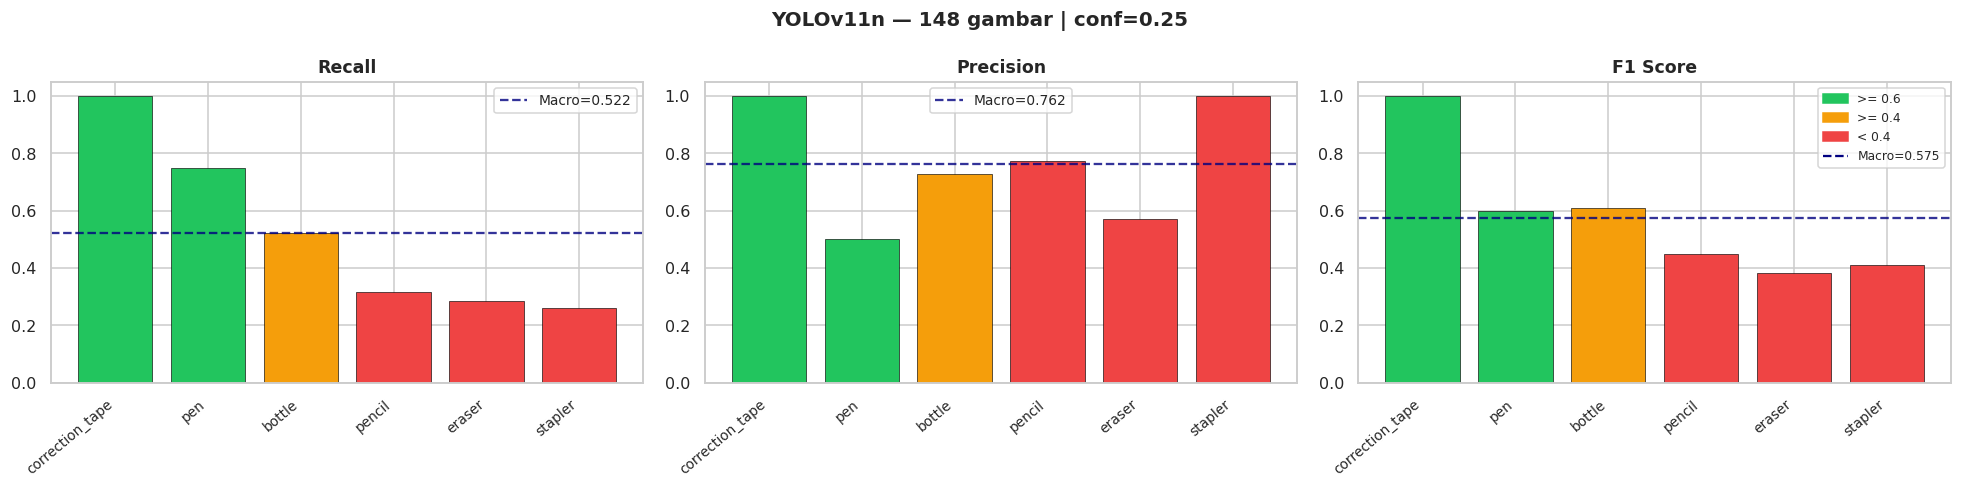

Disimpan: yolo_eval_per_class.png


In [10]:
# Visualisasi per kelas
classes_sorted = df.sort_values('Recall',ascending=False)['Kelas'].tolist()
recalls = [metrics[c]['recall']    for c in classes_sorted]
precs   = [metrics[c]['precision'] for c in classes_sorted]
f1s     = [metrics[c]['f1']        for c in classes_sorted]
colors  = ['#22c55e' if v>=0.6 else ('#f59e0b' if v>=0.4 else '#ef4444') for v in recalls]

x = range(len(classes_sorted))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, vals, label, macro in [
    (axes[0], recalls, 'Recall',    macro_r),
    (axes[1], precs,   'Precision', macro_p),
    (axes[2], f1s,     'F1 Score',  macro_f1),
]:
    ax.bar(x, vals, color=colors, edgecolor='black', linewidth=0.4)
    ax.axhline(macro, color='navy', ls='--', lw=1.5, alpha=0.8, label=f'Macro={macro:.3f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(classes_sorted, rotation=40, ha='right', fontsize=9)
    ax.set_ylim(0,1.05); ax.legend(fontsize=9)
axes[2].legend(handles=[
    mpatches.Patch(color='#22c55e',label='>= 0.6'),
    mpatches.Patch(color='#f59e0b',label='>= 0.4'),
    mpatches.Patch(color='#ef4444',label='< 0.4'),
    plt.Line2D([0],[0],color='navy',ls='--',label=f'Macro={macro_f1:.3f}'),
], fontsize=8)
plt.suptitle(f'YOLOv11n — {len(eval_records)} gambar | conf={CONF_THRESHOLD}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR/'yolo_eval_per_class.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Disimpan: yolo_eval_per_class.png')


PR data: 100%|██████████████████████| 148/148 [00:02<00:00, 69.18it/s]


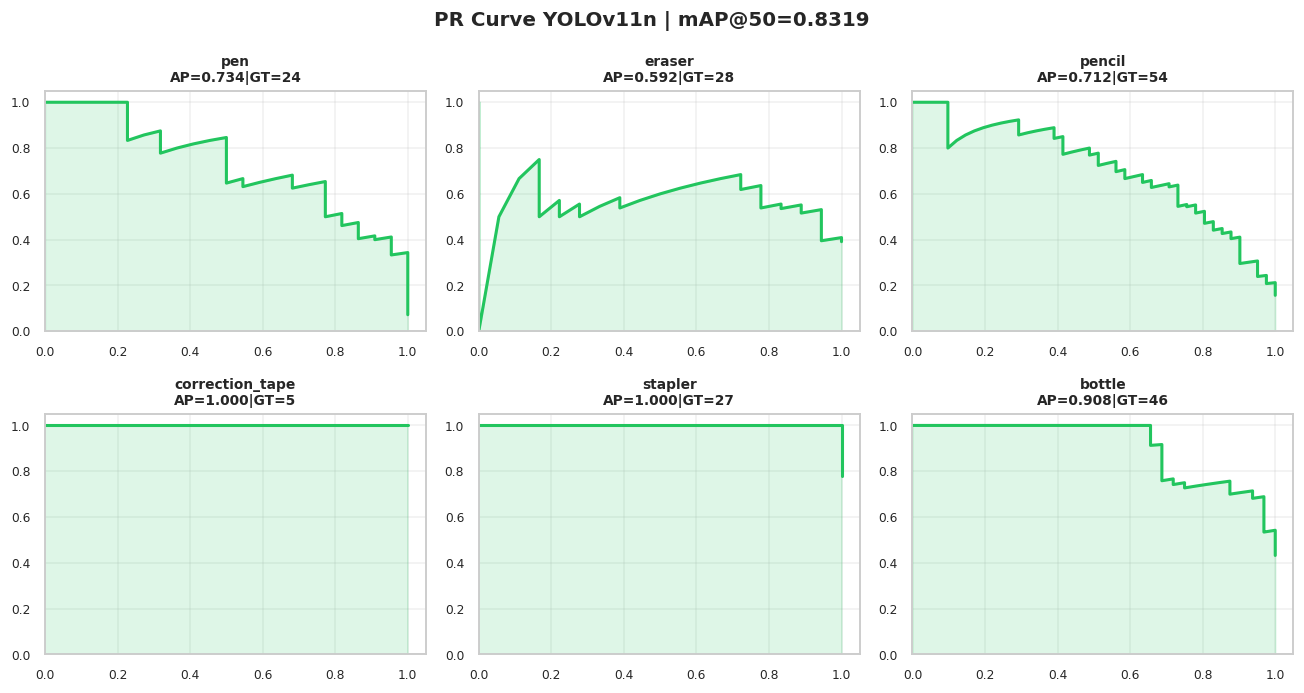

mAP YOLOv11n:
  mAP@30       : 0.8330
  mAP@50       : 0.8319  (standar PASCAL VOC)
  mAP@75       : 0.5475
  mAP@adaptive : 0.8244

  correction_tape        adaptive=1.0000  @50=1.0000
  stapler                adaptive=1.0000  @50=0.9762
  bottle                 adaptive=0.9085  @50=0.9085
  pen                    adaptive=0.7341  @50=0.7606
  pencil                 adaptive=0.7123  @50=0.7545
  eraser                 adaptive=0.5917  @50=0.5917


In [11]:
# PR Curves & mAP
cls_scores = defaultdict(list)
cls_n_gt   = defaultdict(int)

for rec in tqdm(eval_records, desc='PR data', ncols=70):
    try:
        img = load_image_bgr(rec['img_path'])
        if img is None: continue
        H,W = img.shape[:2]
        gt_per_cls = defaultdict(list)
        for b in rec['boxes']:
            if b['class'] not in YOLO_EVAL_CLASSES: continue
            gt_per_cls[b['class']].append(norm_to_pixel(*b['bbox_norm'],W,H))
            cls_n_gt[b['class']] += 1
        all_preds = yolo_predict(img, conf=0.01)
        for cls,gts in gt_per_cls.items():
            preds = sorted([p for p in all_preds if p['class']==cls],
                           key=lambda x:-x['score'])
            matched=set()
            for p in preds:
                best_iou=0.0; best_i=-1
                for i,gt in enumerate(gts):
                    if i in matched: continue
                    iou=iou_box(p['bbox'],gt)
                    if iou>best_iou: best_iou=iou; best_i=i
                if best_i>=0 and best_iou>=ADAPTIVE_IOU.get(cls,IOU_THRESHOLD):
                    matched.add(best_i)
                cls_scores[cls].append((p['score'],best_iou))
    except: pass

cls_with_data = [c for c in YOLO_EVALUABLE if cls_scores.get(c)]
ap_scores={}; ap_multi_iou={}

if not cls_with_data:
    print('Tidak ada data PR.')
else:
    ncols=3; nrows=max(1,math.ceil(len(cls_with_data)/ncols))
    fig,axes = plt.subplots(nrows,ncols,figsize=(ncols*4,nrows*3.2))
    axes = np.array(axes).flatten() if hasattr(axes,'flatten') else np.array([axes])
    for i,cls in enumerate(cls_with_data):
        data=cls_scores[cls]; n_gt=cls_n_gt.get(cls,0)
        scores=np.array([d[0] for d in data]); ious=np.array([d[1] for d in data])
        labels=(ious>=ADAPTIVE_IOU.get(cls,IOU_THRESHOLD)).astype(int)
        aps_at={}
        for iou_t in [0.30,0.50,0.75]:
            lbl=(ious>=iou_t).astype(int)
            aps_at[iou_t]=float(average_precision_score(lbl,scores)) if lbl.sum()>0 else 0.0
        if labels.sum()==0:
            axes[i].set_title(f'{cls}\nAP=0.000|GT={n_gt}',fontsize=9,color='red')
            ap_scores[cls]=0.0; ap_multi_iou[cls]=aps_at
        else:
            try:
                pr,rc,_=precision_recall_curve(labels,scores)
                ap=float(average_precision_score(labels,scores))
                ap_scores[cls]=round(ap,4); ap_multi_iou[cls]=aps_at
                axes[i].plot(rc,pr,color='#22c55e',lw=2)
                axes[i].fill_between(rc,pr,alpha=0.15,color='#22c55e')
                axes[i].set_title(f'{cls}\nAP={ap:.3f}|GT={n_gt}',fontsize=9,fontweight='bold')
                axes[i].set_xlim(0,1.05); axes[i].set_ylim(0,1.05)
                axes[i].tick_params(labelsize=8); axes[i].grid(True,alpha=0.3)
            except: ap_scores[cls]=0.0
    for j in range(len(cls_with_data),len(axes)): axes[j].set_visible(False)
    mAP_50_val = sum(v.get(0.50,0) for v in ap_multi_iou.values())/max(1,len(ap_multi_iou))
    plt.suptitle(f'PR Curve YOLOv11n | mAP@50={mAP_50_val:.4f}',fontsize=13,fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR/'yolo_eval_pr_curves.png'),dpi=120,bbox_inches='tight')
    plt.show()

mAP=float(np.mean(list(ap_scores.values()))) if ap_scores else 0.0
mAP_30=float(np.mean([v.get(0.30,0) for v in ap_multi_iou.values()])) if ap_multi_iou else 0.0
mAP_50=float(np.mean([v.get(0.50,0) for v in ap_multi_iou.values()])) if ap_multi_iou else 0.0
mAP_75=float(np.mean([v.get(0.75,0) for v in ap_multi_iou.values()])) if ap_multi_iou else 0.0

print(f'mAP YOLOv11n:')
print(f'  mAP@30       : {mAP_30:.4f}')
print(f'  mAP@50       : {mAP_50:.4f}  (standar PASCAL VOC)')
print(f'  mAP@75       : {mAP_75:.4f}')
print(f'  mAP@adaptive : {mAP:.4f}')
print()
for cls,ap in sorted(ap_scores.items(),key=lambda x:-x[1]):
    a50=ap_multi_iou.get(cls,{}).get(0.50,0)
    print(f'  {cls:<22} adaptive={ap:.4f}  @50={a50:.4f}')
gc.collect(); torch.cuda.empty_cache()


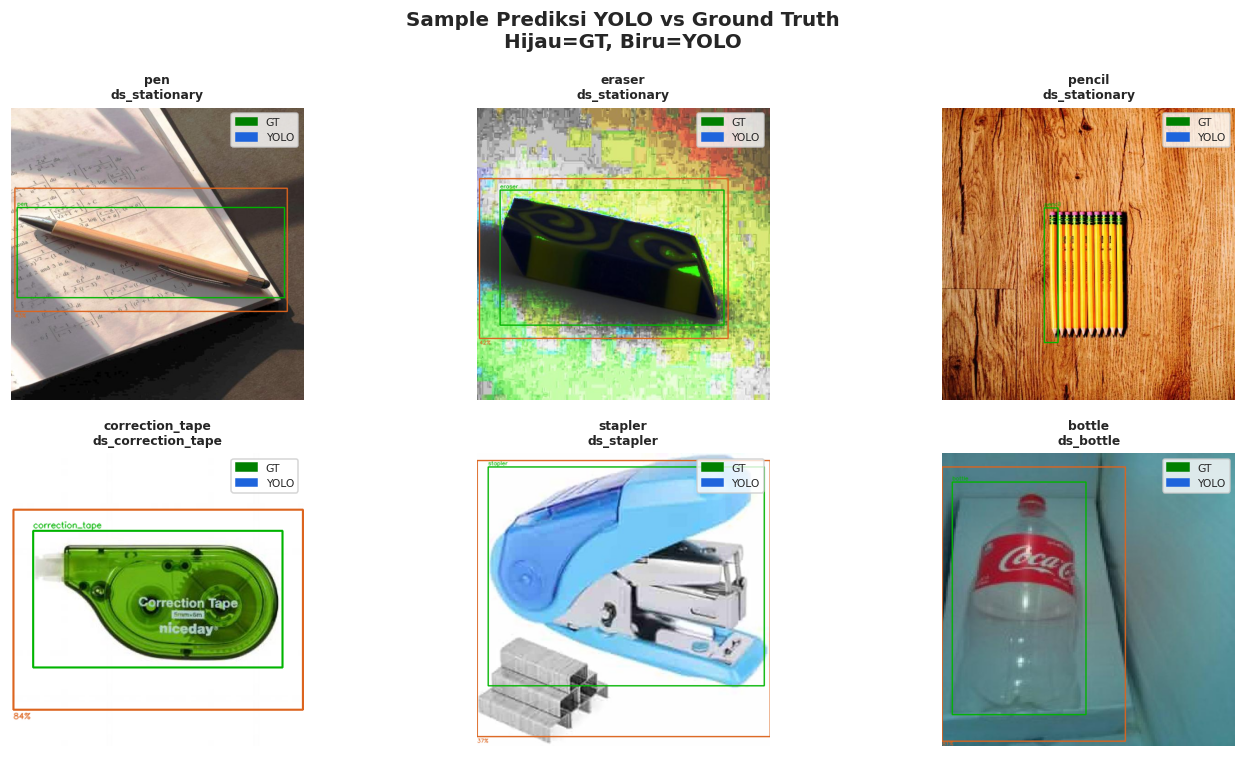

Disimpan: yolo_eval_sample_viz.png


In [12]:
# Sample visualisasi
def draw_compare(img_bgr, gt_boxes, pred_boxes):
    vis = img_bgr.copy(); H,W=vis.shape[:2]
    for b in gt_boxes:
        if b['class'] not in YOLO_EVAL_CLASSES: continue
        px=norm_to_pixel(*b['bbox_norm'],W,H)
        cv2.rectangle(vis,(px[0],px[1]),(px[2],px[3]),(0,180,0),2)
        cv2.putText(vis,b['class'],(px[0],max(px[1]-4,10)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.4,(0,180,0),1,cv2.LINE_AA)
    for p in pred_boxes:
        x1,y1,x2,y2=p['bbox']
        cv2.rectangle(vis,(x1,y1),(x2,y2),(30,100,220),2)
        cv2.putText(vis,f'{p["score"]*100:.0f}%',(x1,min(y2+13,H-2)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.38,(30,100,220),1,cv2.LINE_AA)
    return cv2.cvtColor(vis,cv2.COLOR_BGR2RGB)

sample_recs=[]; seen_cls=set()
for cls in YOLO_EVALUABLE:
    for r in eval_records:
        if any(b['class']==cls for b in r['boxes']) and cls not in seen_cls:
            sample_recs.append((cls,r)); seen_cls.add(cls); break
    if len(sample_recs)>=9: break

if sample_recs:
    ncols=3; nrows=max(1,math.ceil(len(sample_recs)/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*4.5,nrows*3.5))
    axes=np.array(axes).flatten() if hasattr(axes,'flatten') else np.array([axes])
    for i,(cls,rec) in enumerate(sample_recs):
        img=load_image_bgr(rec['img_path'])
        if img is None: axes[i].axis('off'); continue
        preds=yolo_predict(img)
        vis=draw_compare(img,rec['boxes'],preds)
        axes[i].imshow(vis); axes[i].axis('off')
        axes[i].set_title(f'{cls}\n{rec["ds_name"]}',fontsize=8,fontweight='bold')
        axes[i].legend(handles=[
            mpatches.Patch(color='green',label='GT'),
            mpatches.Patch(color='#1e64dc',label='YOLO'),
        ],loc='upper right',fontsize=7)
    for j in range(len(sample_recs),len(axes)): axes[j].set_visible(False)
    plt.suptitle('Sample Prediksi YOLO vs Ground Truth\nHijau=GT, Biru=YOLO',
                 fontsize=13,fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR/'yolo_eval_sample_viz.png'),dpi=110,bbox_inches='tight')
    plt.show()
    print('Disimpan: yolo_eval_sample_viz.png')


In [13]:
# Analisis error
df_err = df.copy()
df_err['FP_rate'] = df_err['FP']/(df_err['TP']+df_err['FP']+1e-6)
df_err['FN_rate'] = df_err['FN']/(df_err['GT']+1e-6)

print('Top 5 — False Positive terbanyak:')
print(df_err.nlargest(5,'FP')[['Kelas','GT','TP','FP','FP_rate']].to_string(index=False))
print()
print('Top 5 — False Negative terbanyak:')
print(df_err.nlargest(5,'FN_rate')[['Kelas','GT','TP','FN','FN_rate']].to_string(index=False))
print()
print('Rekomendasi per kelas:')
for _,row in df.sort_values('Recall',ascending=False).iterrows():
    cls=row['Kelas']; rc=row['Recall']; p=row['Precision']
    if rc>=0.7 and p>=0.5: act='Baik, pertahankan'
    elif rc>=0.7 and p<0.5: act='Recall OK tapi Precision rendah → naikkan conf_threshold'
    elif rc<0.4: act='Recall rendah → model mungkin perlu fine-tuning lebih lanjut'
    else: act='Perlu tuning conf_threshold'
    print(f'  {cls:<22} Recall={rc:.3f}  Prec={p:.3f}  → {act}')


Top 5 — False Positive terbanyak:
          Kelas  GT  TP  FP  FP_rate
            pen  24  18  18 0.500000
         bottle  46  24   9 0.272727
         eraser  28   8   6 0.428571
         pencil  54  17   5 0.227273
correction_tape   5   5   0 0.000000

Top 5 — False Negative terbanyak:
  Kelas  GT  TP  FN  FN_rate
stapler  27   7  20 0.740741
 eraser  28   8  20 0.714286
 pencil  54  17  37 0.685185
 bottle  46  24  22 0.478261
    pen  24  18   6 0.250000

Rekomendasi per kelas:
  correction_tape        Recall=1.000  Prec=1.000  → Baik, pertahankan
  pen                    Recall=0.750  Prec=0.500  → Baik, pertahankan
  bottle                 Recall=0.522  Prec=0.727  → Perlu tuning conf_threshold
  pencil                 Recall=0.315  Prec=0.773  → Recall rendah → model mungkin perlu fine-tuning lebih lanjut
  eraser                 Recall=0.286  Prec=0.571  → Recall rendah → model mungkin perlu fine-tuning lebih lanjut
  stapler                Recall=0.259  Prec=1.000  → Recall 

In [14]:
# Export eval_summary_yolo.json
per_class_metrics = {}
for cls in TARGET_9_CLASSES:
    if cls in metrics:
        m=metrics[cls]; ap=ap_scores.get(cls,0.0)
        aps=ap_multi_iou.get(cls,{})
        per_class_metrics[cls] = {
            'precision'      : m['precision'],
            'recall'         : m['recall'],
            'f1_score'       : m['f1'],
            'ap'             : round(ap,4),
            'ap_50'          : round(aps.get(0.50,0),4),
            'ap_75'          : round(aps.get(0.75,0),4),
            'ap_30'          : round(aps.get(0.30,0),4),
            'true_positives' : m['tp'],
            'false_positives': m['fp'],
            'false_negatives': m['fn'],
            'n_gt'           : m['n_gt'],
            'has_gt'         : True,
        }
    else:
        # Kelas ada di 9 target tapi tidak ada di YOLO
        per_class_metrics[cls] = {
            'precision':0.0,'recall':0.0,'f1_score':0.0,
            'ap':0.0,'ap_50':0.0,'ap_75':0.0,'ap_30':0.0,
            'true_positives':0,'false_positives':0,'false_negatives':0,
            'n_gt':0,'has_gt':False,
        }

summary = {
    'model_name'      : 'yolov11n',
    'model_arch'      : 'YOLOv11n (ultralytics)',
    'ultralytics_ver' : ckpt['version'],
    'training_date'   : ckpt['date'],
    'training_metrics': {
        'mAP50'    : float(ckpt['train_metrics'].get('metrics/mAP50(B)',0)),
        'mAP50_95' : float(ckpt['train_metrics'].get('metrics/mAP50-95(B)',0)),
        'recall'   : float(ckpt['train_metrics'].get('metrics/recall(B)',0)),
        'precision': float(ckpt['train_metrics'].get('metrics/precision(B)',0)),
    },
    'target_classes'    : TARGET_9_CLASSES,
    'yolo_eval_classes' : YOLO_EVAL_CLASSES,
    'yolo_missing_classes': YOLO_MISSING_CLASSES,
    'eval_config': {
        'conf_threshold'  : CONF_THRESHOLD,
        'iou_threshold'   : IOU_THRESHOLD,
        'adaptive_iou'    : ADAPTIVE_IOU,
        'n_eval_images'   : len(eval_records),
        'min_gt_per_class': MIN_GT,
    },
    'overall_map'       : round(mAP,4),
    'overall_map_50'    : round(mAP_50,4),
    'overall_map_75'    : round(mAP_75,4),
    'overall_map_30'    : round(mAP_30,4),
    'overall_precision' : round(macro_p,4),
    'overall_recall'    : round(macro_r,4),
    'overall_f1'        : round(macro_f1,4),
    'macro_metrics': {
        'precision'   : round(macro_p,4),
        'recall'      : round(macro_r,4),
        'f1'          : round(macro_f1,4),
        'mAP_30'      : round(mAP_30,4),
        'mAP_50'      : round(mAP_50,4),
        'mAP_75'      : round(mAP_75,4),
        'mAP_adaptive': round(mAP,4),
    },
    'per_class_metrics': per_class_metrics,
}

out_path = OUT_DIR/'eval_summary_yolo.json'
with open(out_path,'w') as f: json.dump(summary,f,indent=2)
print(f'eval_summary_yolo.json disimpan: {out_path}')
print(f'  Size: {out_path.stat().st_size/1024:.1f} KB')
print()
print(f'  {"Kelas":<22} {"Precision":>10} {"Recall":>8} {"F1":>8} {"AP@50":>8} {"GT":>5}')
for cls in TARGET_9_CLASSES:
    m=per_class_metrics[cls]
    if m['has_gt']:
        print(f'  {cls:<22} {m["precision"]:>10.4f} {m["recall"]:>8.4f} '
              f'{m["f1_score"]:>8.4f} {m["ap_50"]:>8.4f} {m["n_gt"]:>5}')
    else:
        print(f'  {cls:<22} (tidak ada di YOLO model)')


eval_summary_yolo.json disimpan: /content/eval_results_yolo/eval_summary_yolo.json
  Size: 3.9 KB

  Kelas                   Precision   Recall       F1    AP@50    GT
  pen                        0.5000   0.7500   0.6000   0.7606    24
  pencil                     0.7727   0.3148   0.4474   0.7545    54
  eraser                     0.5714   0.2857   0.3810   0.5917    28
  sharpener              (tidak ada di YOLO model)
  correction_tape            1.0000   1.0000   1.0000   1.0000     5
  stapler                    1.0000   0.2593   0.4118   0.9762    27
  clip                   (tidak ada di YOLO model)
  bottle                     0.7273   0.5217   0.6076   0.9085    46
  notebook               (tidak ada di YOLO model)


In [15]:
# Download
print('File yang dihasilkan:')
for p in sorted(OUT_DIR.glob('*')):
    print(f'  {p.name}  ({p.stat().st_size/1024:.1f} KB)')

from google.colab import files as colab_files
print('\nDownload eval_summary_yolo.json (FILE UTAMA untuk WBF Ensemble)...')
try:
    colab_files.download(str(OUT_DIR/'eval_summary_yolo.json'))
    print('  OK')
except Exception as e:
    print(f'  Error: {e}')

for fname in ['yolo_eval_main.csv','yolo_eval_per_class.png',
              'yolo_eval_pr_curves.png','yolo_eval_sample_viz.png']:
    fp=OUT_DIR/fname
    if fp.exists():
        try: colab_files.download(str(fp)); print(f'  OK: {fname}')
        except: pass


File yang dihasilkan:
  eval_summary_yolo.json  (3.9 KB)
  yolo_eval_main.csv  (0.2 KB)
  yolo_eval_per_class.png  (57.8 KB)
  yolo_eval_pr_curves.png  (61.4 KB)
  yolo_eval_sample_viz.png  (747.0 KB)

Download eval_summary_yolo.json (FILE UTAMA untuk WBF Ensemble)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  OK: yolo_eval_pr_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK: yolo_eval_sample_viz.png
